# Notebook 7 — Ground Truth Room Label Rasterizer

**Stage GT file · runs after Notebook 1**

> **Pipeline execution order: `6 -> 1 -> 2 -> 4 -> 7 -> 8`.**
> Notebook 7 reads the raw S3DIS `Area_3/` room folders and rasterises each room's full
> point cloud onto the **exact Stage 1 pixel grid** (via `transform.json`), producing a
> ground-truth room-label map in the same shape + coordinate frame as the watershed's
> `room_labels.npy`. Notebook 8 scores the predictions against it.

## Purpose
Build `gt_room_labels.npy`: per-pixel ground-truth room membership on the Stage 1 grid.

## Inputs
- `stage1_occupancy/transform.json` — the pixel<->world grid (Notebook 1).
- `data/Area_3/<room>/<room>.txt` — each room's full point cloud (`X Y Z R G B`).

## Outputs  (`{out_root}/stage_gt/`)
- `gt_room_labels.npy` — int32, shape `(H, W)`: `0` = exterior, `>=1` = room id.
- `gt_room_labels_color.png` — colourised QA image.

## Assumptions
- Notebook 1 has been run on `area3_structural.ply`, so `transform.json` is in the Area_3
  frame. Each room folder gets a 1-based id (sorted folder order), matching the
  `>=1 == room` convention of `room_labels.npy`. Walls are **not** marked `-1` here — GT is
  room membership only; Notebook 8 treats unmatched pixels as exterior.

### Setup
**Run-All ready.** Edit **`params.yaml`** (the only config surface), then run every cell top
to bottom. `load_config()` reads it over the `Config` defaults.

In [1]:
# ============================== scan2bim setup (local) ==============================
import os
import numpy as np
import scan2bim
from scan2bim import artifacts as A

CFG = scan2bim.load_config()        # params.yaml over Config defaults
SHOW_DEBUG = True                   # set False to skip the QA plot
ROOT = scan2bim.project_root()
AREA_DIR = os.path.join(ROOT, 'data', 'Area_3')
STAGE_GT = 'stage_gt'               # GT artifacts land in {out_root}/stage_gt/
print('scan2bim', scan2bim.__version__, 'loaded from', os.path.dirname(scan2bim.__file__))
print('Area dir    :', AREA_DIR, '| exists:', os.path.isdir(AREA_DIR))
print('output root :', CFG.out_root)

scan2bim 1.0.0 loaded from C:\onestruction\scan2bim
Area dir    : C:\onestruction\data\Area_3 | exists: True
output root : C:\onestruction\scan2bim_out


### Step 1 — Load the Stage 1 grid (`transform.json`)
The GT must align pixel-for-pixel with the watershed output, so it is projected through the
**same** transform Notebook 1 wrote.

In [2]:
s1 = A.load_stage_dir(CFG.out_root, A.STAGE1)
tf = A.load_transform(os.path.join(s1, A.TRANSFORM_JSON))
H, W = tf['height'], tf['width']
print('grid (H x W):', (H, W), '| pixel_size:', tf['pixel_size'], 'm')

grid (H x W): (856, 1011) | pixel_size: 0.03 m


### Step 2 — Collect room folders (sorted) and assign 1-based ids

In [3]:
rooms = sorted(d for d in os.listdir(AREA_DIR)
               if os.path.isdir(os.path.join(AREA_DIR, d)))
room_ids = {name: i + 1 for i, name in enumerate(rooms)}
print('rooms:', len(rooms))
for name in rooms:
    print('  %3d  %s' % (room_ids[name], name))

rooms: 23
    1  WC_1
    2  WC_2
    3  conferenceRoom_1
    4  hallway_1
    5  hallway_2
    6  hallway_3
    7  hallway_4
    8  hallway_5
    9  hallway_6
   10  lounge_1
   11  lounge_2
   12  office_1
   13  office_10
   14  office_2
   15  office_3
   16  office_4
   17  office_5
   18  office_6
   19  office_7
   20  office_8
   21  office_9
   22  storage_1
   23  storage_2


### Step 3 — Rasterise each room's full cloud onto the grid
`point_cells` maps world XYZ to `(row, col)` under `tf`. Pixels no room hits stay `0`
(exterior, the `np.zeros` default); walls are intentionally **not** marked `-1`.

In [4]:
def load_room_xyz(path):
    # Fast path for clean files; a few S3DIS rows carry a stray control char (e.g. '-9.1\x16'),
    # so on failure re-read with a per-field sanitizing converter (slower, used only as needed).
    try:
        return np.loadtxt(path, usecols=(0, 1, 2), dtype=np.float64)
    except ValueError:
        import re
        clean = lambda s: float(re.sub(r'[^0-9eE.+-]', '', s.decode() if isinstance(s, bytes) else s))
        return np.loadtxt(path, usecols=(0, 1, 2), dtype=np.float64,
                          converters={0: clean, 1: clean, 2: clean})

gt_labels = np.zeros((H, W), dtype=np.int32)
for name in rooms:
    rid = room_ids[name]
    pts = load_room_xyz(os.path.join(AREA_DIR, name, name + '.txt'))
    row, col, inb = scan2bim.point_cells(pts, tf)
    gt_labels[row[inb], col[inb]] = rid
    print('%-18s id=%3d  %9d pts  %7d px  (%.1f%% in-grid)'
          % (name, rid, len(pts), int(inb.sum()), 100.0 * inb.mean()))

WC_1               id=  1    1049844 pts  1049844 px  (100.0% in-grid)


WC_2               id=  2    1141736 pts  1141736 px  (100.0% in-grid)


conferenceRoom_1   id=  3    1266990 pts  1266990 px  (100.0% in-grid)


hallway_1          id=  4     973222 pts   973222 px  (100.0% in-grid)


hallway_2          id=  5    1193228 pts  1193228 px  (100.0% in-grid)
hallway_3          id=  6     175075 pts   175075 px  (100.0% in-grid)


...

office_5           id= 17     800364 pts   800299 px  (100.0% in-grid)


office_6           id= 18     760942 pts   760942 px  (100.0% in-grid)


office_7           id= 19     839708 pts   839708 px  (100.0% in-grid)


office_8           id= 20     982865 pts   982865 px  (100.0% in-grid)
office_9           id= 21     603754 pts   603754 px  (100.0% in-grid)


storage_1          id= 22     178968 pts   176907 px  (98.8% in-grid)
storage_2          id= 23      93170 pts    93170 px  (100.0% in-grid)


### Step 4 — Save GT labels + colourised PNG

In [5]:
out_dir = A.ensure_dir(A.stage_dir(CFG.out_root, STAGE_GT))
gt_npy = os.path.join(out_dir, 'gt_room_labels.npy')
A.save_npy(gt_npy, gt_labels)
A.save_label_png(os.path.join(out_dir, 'gt_room_labels_color.png'), gt_labels)
ids = [int(v) for v in np.unique(gt_labels) if v >= 1]
print('unique room ids in GT:', len(ids), '->', ids)
print('packaged ->', gt_npy)

unique room ids in GT: 23 -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
packaged -> C:\onestruction\scan2bim_out\stage_gt\gt_room_labels.npy


### Optional — QA plot (GT vs. the Stage 2 watershed rooms)

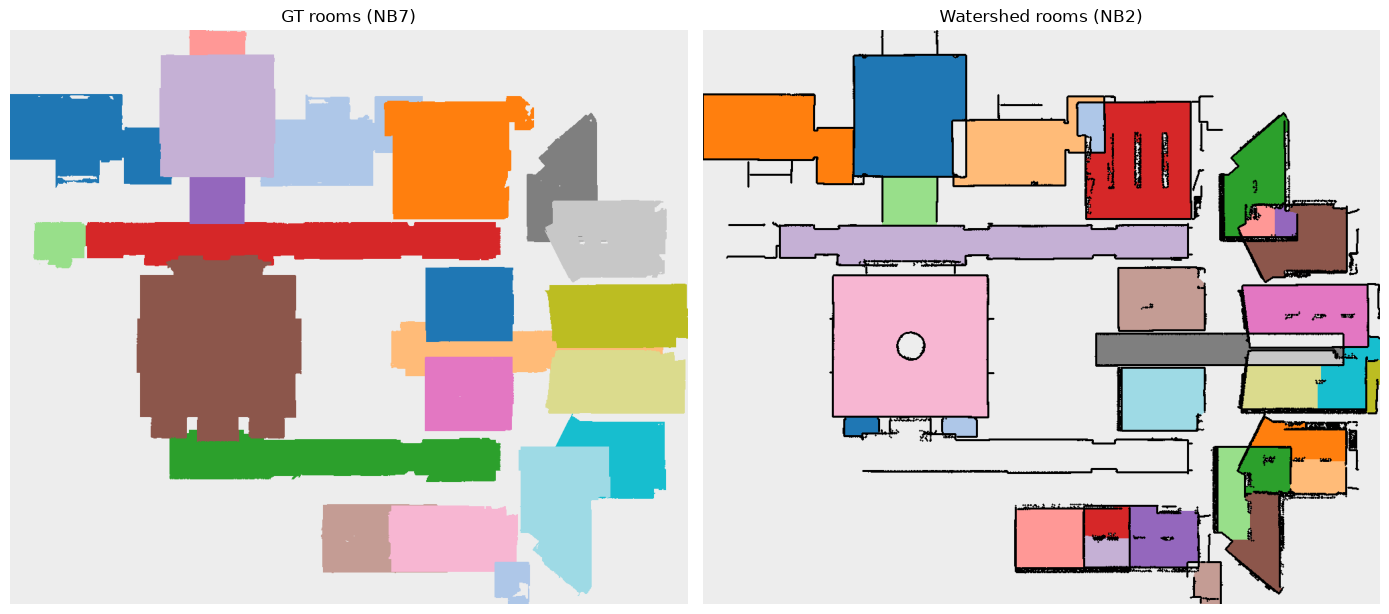

In [6]:
if SHOW_DEBUG:
    import matplotlib.pyplot as plt
    from PIL import Image
    gt_img = Image.open(os.path.join(out_dir, 'gt_room_labels_color.png'))
    s2 = A.load_stage_dir(CFG.out_root, A.STAGE2)
    geom_img = Image.open(os.path.join(s2, A.ROOM_LABELS_PNG))
    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    ax[0].imshow(gt_img);  ax[0].set_title('GT rooms (NB7)');        ax[0].axis('off')
    ax[1].imshow(geom_img); ax[1].set_title('Watershed rooms (NB2)'); ax[1].axis('off')
    plt.tight_layout(); plt.show()